In [77]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [78]:
"""
EDA Visualization Functions for Energy Market Analysis
Simple modular functions for time series visualization
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

def load_meta_labels(meta_path):
    """
    Load label mapping from meta_data_library.
    
    Args:
        meta_path (str): Path to meta_data_library.csv
    
    Returns:
        dict: Mapping of column_name -> label
    """
    try:
        # Try UTF-8 first
        meta = pd.read_csv(meta_path, encoding='utf-8')
        return dict(zip(meta['column_name'], meta['label']))
    except UnicodeDecodeError:
        # Fallback to Windows encoding
        try:
            meta = pd.read_csv(meta_path, encoding='cp1252')
            return dict(zip(meta['column_name'], meta['label']))
        except Exception as e:
            print(f"Warning: Could not load meta_data_library.csv: {e}")
            return {}
    except Exception as e:
        print(f"Warning: Could not load meta_data_library.csv: {e}")
        return {}

def get_label(column, label_dict):
    """
    Get label for column or return column name as fallback.
    
    Args:
        column (str): Column name
        label_dict (dict): Label mapping dictionary
    
    Returns:
        str: Label or column name
    """
    if column in label_dict:
        return label_dict[column]
    else:
        print(f"Warning: meta_data_library.csv incomplete. Displaying column name instead: {column}")
        return column

def format_date_ym(date_str):
    """
    Format date string to YYYY-MM.
    
    Args:
        date_str (str): Date in format YYYY-MM-DD
    
    Returns:
        str: Date in format YYYY-MM
    """
    return date_str[:7]

def single_plot(df, column, time_window, aggregation_level, meta_library_path,
                figsize=(12, 6)):
    """
    Plot single time series variable.
    
    Args:
        df (DataFrame): Data with date_dt column
        column (str): Column name to plot
        time_window (list): [start_date, end_date] as strings 'YYYY-MM-DD'
        aggregation_level (str): 'daily', 'weekly', or 'monthly'
        meta_library_path (str): Path to meta_data_library.csv
        figsize (tuple): Figure size
    """
    # Load labels
    label_dict = load_meta_labels(meta_library_path)
    label = get_label(column, label_dict)
    
    # Filter data
    df_filtered = df[df['aggregation_level'] == aggregation_level].copy()
    df_filtered = df_filtered[
        (df_filtered['date_dt'] >= time_window[0]) & 
        (df_filtered['date_dt'] <= time_window[1])
    ]
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df_filtered['date_dt'], df_filtered[column], linewidth=2)
    
    # Format dates for title
    start_ym = format_date_ym(time_window[0])
    end_ym = format_date_ym(time_window[1])
    
    # Set title and labels
    ax.set_title(f"{label} Time Plot {start_ym} to {end_ym}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    
    plt.tight_layout()
    plt.show()

def dual_axis_plot(df, primary_columns, secondary_columns, time_window, aggregation_level,
                   meta_library_path, figsize=(12, 6)):
    """
    Plot multiple variables on dual y-axes.
    
    Args:
        df (DataFrame): Data with date_dt column
        primary_columns (list): Column names for primary (left) y-axis
        secondary_columns (list): Column names for secondary (right) y-axis
        time_window (list): [start_date, end_date] as strings 'YYYY-MM-DD'
        aggregation_level (str): 'daily', 'weekly', or 'monthly'
        meta_library_path (str): Path to meta_data_library.csv
        figsize (tuple): Figure size
    """
    # Load labels
    label_dict = load_meta_labels(meta_library_path)
    
    # Filter data
    df_filtered = df[df['aggregation_level'] == aggregation_level].copy()
    df_filtered = df_filtered[
        (df_filtered['date_dt'] >= time_window[0]) & 
        (df_filtered['date_dt'] <= time_window[1])
    ]
    
    # Create plot with dual axes
    fig, ax1 = plt.subplots(figsize=figsize)
    ax2 = ax1.twinx()
    
    # Plot primary columns on left axis
    for col in primary_columns:
        label = get_label(col, label_dict)
        ax1.plot(df_filtered['date_dt'], df_filtered[col], label=label, linewidth=2)
    
    # Plot secondary columns on right axis
    for col in secondary_columns:
        label = get_label(col, label_dict)
        ax2.plot(df_filtered['date_dt'], df_filtered[col], label=label, 
                linewidth=2, linestyle='--')
    
    # Format dates for title
    start_ym = format_date_ym(time_window[0])
    end_ym = format_date_ym(time_window[1])
    
    # Set title
    ax1.set_title(f"Combined Time Plot {start_ym} to {end_ym}", 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel("Date", fontsize=12)
    ax1.set_ylabel("Primary Axis", fontsize=12)
    ax2.set_ylabel("Secondary Axis", fontsize=12)
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    
    plt.tight_layout()
    plt.show()

def standard_axis_plot(df, columns, time_window, aggregation_level, meta_library_path,
                      figsize=(12, 6)):
    """
    Plot multiple variables with 0-100 standardization on shared axis.
    
    Args:
        df (DataFrame): Data with date_dt column
        columns (list): Column names to plot
        time_window (list): [start_date, end_date] as strings 'YYYY-MM-DD'
        aggregation_level (str): 'daily', 'weekly', or 'monthly'
        meta_library_path (str): Path to meta_data_library.csv
        figsize (tuple): Figure size
    """
    # Load labels
    label_dict = load_meta_labels(meta_library_path)
    
    # Filter data
    df_filtered = df[df['aggregation_level'] == aggregation_level].copy()
    df_filtered = df_filtered[
        (df_filtered['date_dt'] >= time_window[0]) & 
        (df_filtered['date_dt'] <= time_window[1])
    ]
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Normalize and plot each column
    for col in columns:
        # Min-Max normalization to 0-100
        col_data = df_filtered[col].dropna()
        if len(col_data) > 0:
            col_min = col_data.min()
            col_max = col_data.max()
            if col_max - col_min > 0:
                normalized = ((df_filtered[col] - col_min) / (col_max - col_min)) * 100
            else:
                normalized = df_filtered[col] * 0  # All same value -> 0
            
            label = get_label(col, label_dict)
            ax.plot(df_filtered['date_dt'], normalized, label=label, linewidth=2)
    
    # Format dates for title
    start_ym = format_date_ym(time_window[0])
    end_ym = format_date_ym(time_window[1])
    
    # Set title and labels
    ax.set_title(f"Combined Time Plot {start_ym} to {end_ym}", 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Normalized Scale (0-100)", fontsize=12)
    ax.set_ylim(-5, 105)
    ax.legend(loc='best')
    
    plt.tight_layout()
    plt.show()


# Example usage (commented out)
"""
# Load data
df = pd.read_csv('data/processed/data_consolidated.csv')
df['date_dt'] = pd.to_datetime(df['date'])

# Define paths and time windows
meta_lib_path = '../data/metadata/meta_data_library.csv'
main = ['2020-01-01', '2023-12-31']

# Single plot
single_plot(df, 'price_exaa_mean', main, 'monthly', meta_lib_path)

# Dual axis plot
dual_axis_plot(df, ['price_exaa_mean'], ['carbonprices_primary_market'],
               main, 'monthly', meta_lib_path)

# Standard axis plot
standard_axis_plot(df, ['price_exaa_mean', 'carbonprices_primary_market', 'climate_hdd_at'],
                   main, 'monthly', meta_lib_path)
"""

"\n# Load data\ndf = pd.read_csv('data/processed/data_consolidated.csv')\ndf['date_dt'] = pd.to_datetime(df['date'])\n\n# Define paths and time windows\nmeta_lib_path = '../data/metadata/meta_data_library.csv'\nmain = ['2020-01-01', '2023-12-31']\n\n# Single plot\nsingle_plot(df, 'price_exaa_mean', main, 'monthly', meta_lib_path)\n\n# Dual axis plot\ndual_axis_plot(df, ['price_exaa_mean'], ['carbonprices_primary_market'],\n               main, 'monthly', meta_lib_path)\n\n# Standard axis plot\nstandard_axis_plot(df, ['price_exaa_mean', 'carbonprices_primary_market', 'climate_hdd_at'],\n                   main, 'monthly', meta_lib_path)\n"

In [79]:
# Load finalized data
df = pd.read_csv('../data/processed/data_finalized.csv', encoding='cp1252')

In [80]:
meta_lib_path = '../data/metadata/meta_data_library.csv'
main = ['2020-01-01', '2025-12-31']
corona = ['2020-03-01', '2021-12-31']
energy_crisis = ['2022-01-01', '2023-12-31']

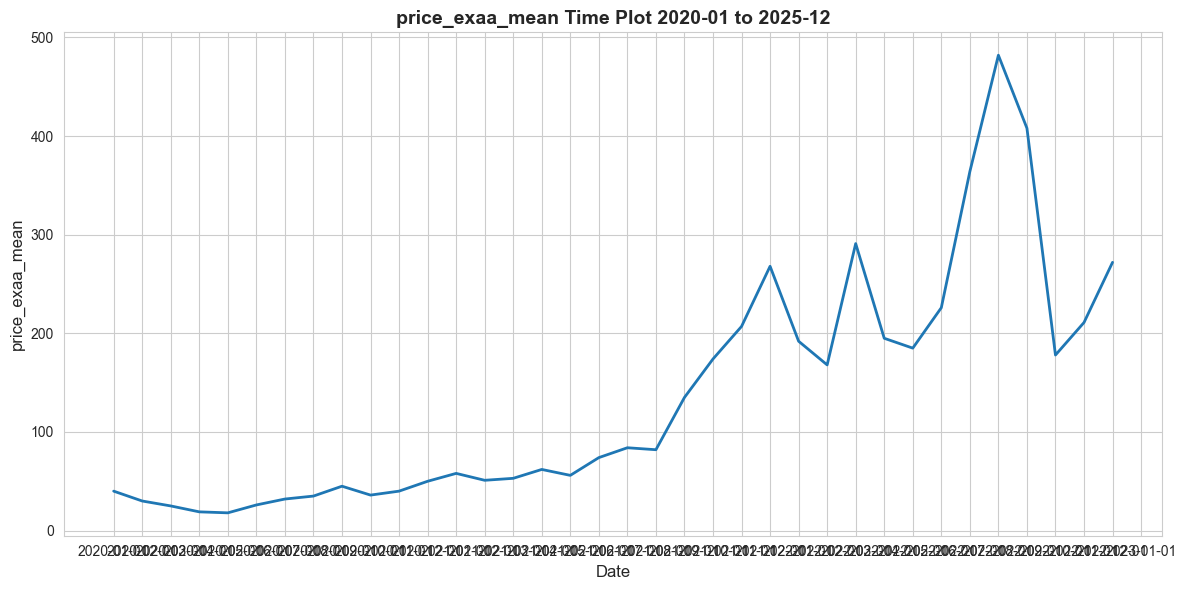

In [81]:
# # Single plot
# single_plot(df, 'price_exaa_mean', main, 'monthly', meta_lib_path)
single_plot(df, 'price_exaa_mean', main, 'monthly', meta_lib_path)

In [82]:
# # Dual axis plot
# dual_axis_plot(df, ['price_exaa_mean'], ['carbonprices_primary_market'],
#                main, 'monthly', meta_lib_path)

In [83]:
# # Standard axis plot
# standard_axis_plot(df, ['price_exaa_mean', 'carbonprices_primary_market', 'climate_hdd_at'],
#                    main, 'monthly', meta_lib_path)